In [16]:
import nltk
from string import punctuation

nltk.download('punkt')
nltk.download('punkt_tab')

ficheiros = ['Harry_Potter.txt', 'Harry_Potter_Camara_Secreta-br.txt']

sentences_hp = []

for nome_f in ficheiros:
    with open(nome_f, 'r', encoding='utf-8') as f:
        texto = f.read().lower()
        frases = nltk.tokenize.sent_tokenize(texto)  # Divide o texto em frases usando o nltk
        for frase in frases:
            palavras = [p.strip(punctuation) for p in frase.split() if p.strip(punctuation)]
            if palavras:
                sentences_hp.append(palavras)
                
print(f"Total de frases carregadas: {len(sentences_hp)}")
print(f"Exemplo de frase tokenizada: {sentences_hp[0]}")                

Total de frases carregadas: 13147
Exemplo de frase tokenizada: ['dados', 'de', 'copyright', 'sobre', 'a', 'obra', 'a', 'presente', 'obra', 'é', 'disponibilizada', 'pela', 'equipe', 'le', 'livros', 'e', 'seus', 'diversos', 'parceiros', 'com', 'o', 'objetivo', 'de', 'oferecer', 'conteúdo', 'para', 'uso', 'parcial', 'em', 'pesquisas', 'e', 'estudos', 'acadêmicos', 'bem', 'como', 'o', 'simples', 'teste', 'da', 'qualidade', 'da', 'obra', 'com', 'o', 'fim', 'exclusivo', 'de', 'compra', 'futura']


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/jessicacunha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/jessicacunha/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [17]:
from gensim.models import Word2Vec

model_hp = Word2Vec(
    sentences=sentences_hp, 
    vector_size=300, 
    window=5, 
    min_count=2,  # Ignora palavras que aparecem apenas uma vez
    sg=0,  
    epochs=20,  
    workers=3
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [18]:
model_hp.wv.save_word2vec_format('model_harry.txt', binary=False)
#http://projector.tensorflow.org/

In [19]:
!python3 -m gensim.scripts.word2vec2tensor --i model_harry.txt --o model_harry

2026-04-14 18:51:35,759 - word2vec2tensor - INFO - running /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/gensim/scripts/word2vec2tensor.py --i model_harry.txt --o model_harry
2026-04-14 18:51:35,759 - keyedvectors - INFO - loading projection weights from model_harry.txt
2026-04-14 18:51:36,729 - utils - INFO - KeyedVectors lifecycle event {'msg': 'loaded (7013, 300) matrix of type float32 from model_harry.txt', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-04-14T18:51:36.713070', 'gensim': '4.4.0', 'python': '3.11.5 (v3.11.5:cce6ba91b3, Aug 24 2023, 10:50:31) [Clang 13.0.0 (clang-1300.0.29.30)]', 'platform': 'macOS-26.1-arm64-arm-64bit', 'event': 'load_word2vec_format'}
2026-04-14 18:51:43,595 - word2vec2tensor - INFO - 2D tensor file saved to model_harry_tensor.tsv
2026-04-14 18:51:43,596 - word2vec2tensor - INFO - Tensor metadata file saved to model_harry_metadata.tsv
2026-04-14 18:51:43,596 - word2vec2tensor - INFO - finished running word2v

In [20]:

grupos = [
    ['harry', 'hermione', 'ron', 'dumbledore', 'vassoura'],
    ['grifinória', 'sonserina', 'lufa-lufa', 'corvinal', 'quadribol'],
    ['varinha', 'vassoura', 'capa', 'feitiço', 'carro'],
]

for grupo in grupos:
    intruso = model_hp.wv.doesnt_match(grupo)
    print(f'Grupo {grupo} → intruso: "{intruso}"')

Grupo ['harry', 'hermione', 'ron', 'dumbledore', 'vassoura'] → intruso: "vassoura"
Grupo ['grifinória', 'sonserina', 'lufa-lufa', 'corvinal', 'quadribol'] → intruso: "quadribol"
Grupo ['varinha', 'vassoura', 'capa', 'feitiço', 'carro'] → intruso: "feitiço"


In [21]:

pares = [
    ('harry', 'hermione'),
    ('harry', 'voldemort'),
    ('hogwarts', 'escola'),
    ('varinha', 'vassoura'),
    ('harry', 'vassoura'),
    ('grifinória', 'sonserina'),
]

for w1, w2 in pares:
    print(f"Similaridade entre '{w1}' e '{w2}': {model_hp.wv.similarity(w1, w2):.4f}")

Similaridade entre 'harry' e 'hermione': 0.6696
Similaridade entre 'harry' e 'voldemort': 0.1563
Similaridade entre 'hogwarts' e 'escola': 0.5860
Similaridade entre 'varinha' e 'vassoura': 0.7974
Similaridade entre 'harry' e 'vassoura': 0.4590
Similaridade entre 'grifinória' e 'sonserina': 0.8769


In [22]:

print("Semelhantes a 'harry':", model_hp.wv.most_similar('harry', topn=5))

print("Semelhantes a 'voldemort':", model_hp.wv.most_similar('voldemort', topn=5))

print("Semelhantes a 'hogwarts':", model_hp.wv.most_similar('hogwarts', topn=5))

print("Semelhantes a 'Gryffindor':", model_hp.wv.most_similar('grifinória', topn=5))

print("Semelhantes a 'Lufa-Lufa':", model_hp.wv.most_similar('lufa-lufa', topn=5))

print("Semelhantes a 'Azkaban':", model_hp.wv.most_similar('azkaban', topn=5))

print("Semelhantes a 'Snape':", model_hp.wv.most_similar('snape', topn=5))

Semelhantes a 'harry': [('neville', 0.728363037109375), ('ele', 0.7005473971366882), ('hermione', 0.6696286797523499), ('draco', 0.6545754075050354), ('mione', 0.6483416557312012)]
Semelhantes a 'voldemort': [('gringotes', 0.8331572413444519), ('você-sabe-quem', 0.8319950699806213), ('dinheiro', 0.8216444849967957), ('morrer', 0.8198599219322205), ('reconhecer', 0.8188055753707886)]
Semelhantes a 'hogwarts': [('gringotes', 0.7685964703559875), ('dinheiro', 0.7672736048698425), ('usar', 0.7417893409729004), ('paz', 0.7380490303039551), ('londres', 0.7172826528549194)]
Semelhantes a 'Gryffindor': [('lufa-lufa', 0.8981656432151794), ('sonserina', 0.8768562078475952), ('corvinal', 0.8516247868537903), ('torre', 0.8031152486801147), ('escola', 0.7770867943763733)]
Semelhantes a 'Lufa-Lufa': [('corvinal', 0.9255334734916687), ('grifinória', 0.8981655240058899), ('sonserina', 0.8626384139060974), ('existência', 0.8299210667610168), ('cidadezinha', 0.8292068243026733)]
Semelhantes a 'Azkaban':

In [23]:
def analogy(x, y, z):
    result = model_hp.wv.most_similar(positive=[y, z], negative=[x])
    return result[0][0]

print(f"Harry -> grifinória | draco -> {analogy('harry', 'grifinória', 'draco')}")

print(f"Hogwarts -> Escola | Quadribol -> {analogy('hogwarts', 'escola', 'quadribol')}")

print(f"Harry -> varinha | nimbus -> {analogy('harry', 'varinha', 'nimbus')}")

print(f"Dumbledore -> hogwarts | voldemort -> {analogy('dumbledore', 'hogwarts', 'voldemort')}")

print(f"Harry -> Hermione | Rony -> {analogy('harry', 'hermione', 'rony')}")

print(f"Snape -> professor | Draco -> {analogy('snape', 'professor', 'draco')}")

print(f"Voldemort -> maldade | Dumbledore -> {analogy('voldemort', 'maldade', 'dumbledore')}")

print(f"Harry -> vassoura | Draco -> {analogy('harry', 'vassoura', 'draco')}")

print(f"Hermione -> inteligência | comida -> {analogy('hermione', 'inteligência', 'comida')}")

print(f"Hermione -> inteligência | Rony -> {analogy('hermione', 'inteligência', 'rony')}")


Harry -> grifinória | draco -> lufa-lufa
Hogwarts -> Escola | Quadribol -> sonserina
Harry -> varinha | nimbus -> bigodeira
Dumbledore -> hogwarts | voldemort -> usar
Harry -> Hermione | Rony -> mione
Snape -> professor | Draco -> lúcio
Voldemort -> maldade | Dumbledore -> desdenhoso
Harry -> vassoura | Draco -> carta
Hermione -> inteligência | comida -> cadentes
Hermione -> inteligência | Rony -> escorrendo


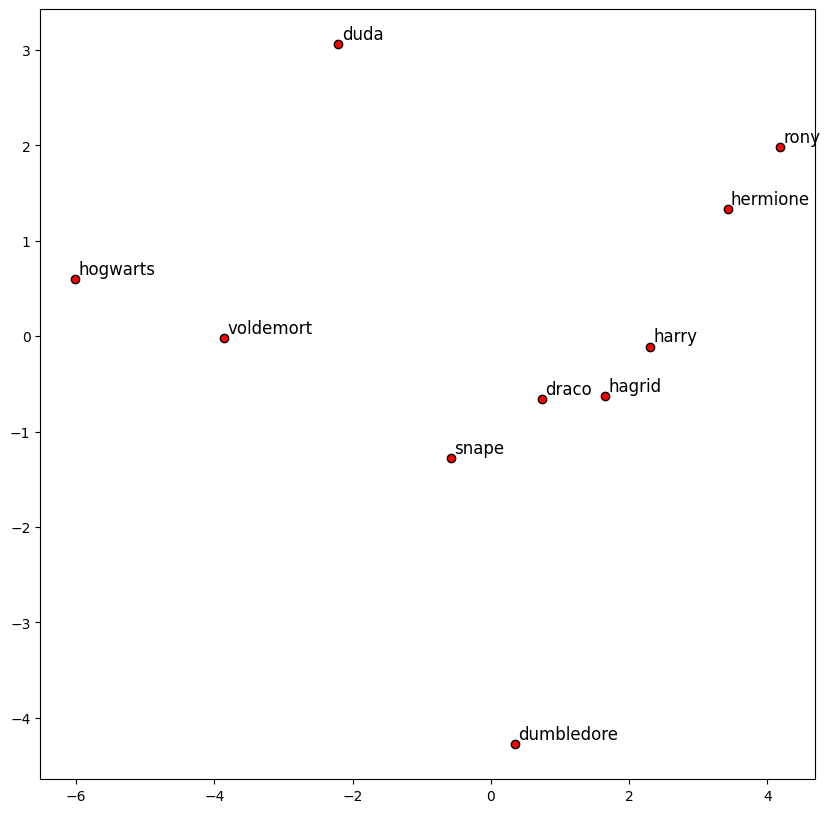

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def display_pca_scatterplot(model, words=None):
    word_vectors = np.array([model.wv[w] for w in words])
    twodim = PCA().fit_transform(word_vectors)[:,:2]
    
    plt.figure(figsize=(10,10))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='red')
    for word, (x,y) in zip(words, twodim):
        plt.text(x+0.05, y+0.05, word, fontsize=12)
    plt.show()

termos = ['harry', 'rony', 'hermione', 'voldemort', 'dumbledore', 'snape', 'draco', 'hagrid', 'hogwarts', 'duda']
display_pca_scatterplot(model_hp, termos)

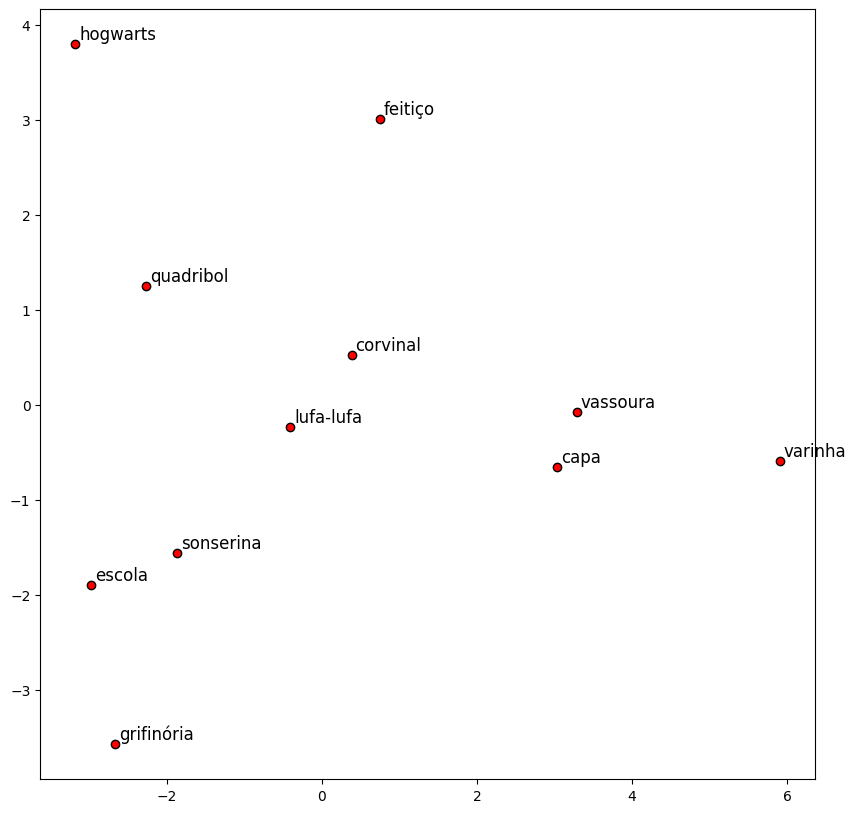

In [25]:
cores_casas = {
    'grifinória':  '#c0392b',  # vermelho
    'sonserina':   '#27ae60',  # verde
    'lufa-lufa':   '#f39c12',  # amarelo
    'corvinal':    '#2980b9',  # azul
    'quadribol':   '#888888',
    'varinha':     '#8e44ad',
    'vassoura':    '#8e44ad',
    'capa':        '#8e44ad',
    'feitiço':     '#8e44ad',
    'hogwarts':    '#2c3e50',
    'escola':      '#2c3e50',
}

termos2 = list(cores_casas.keys())
display_pca_scatterplot(model_hp, termos2)

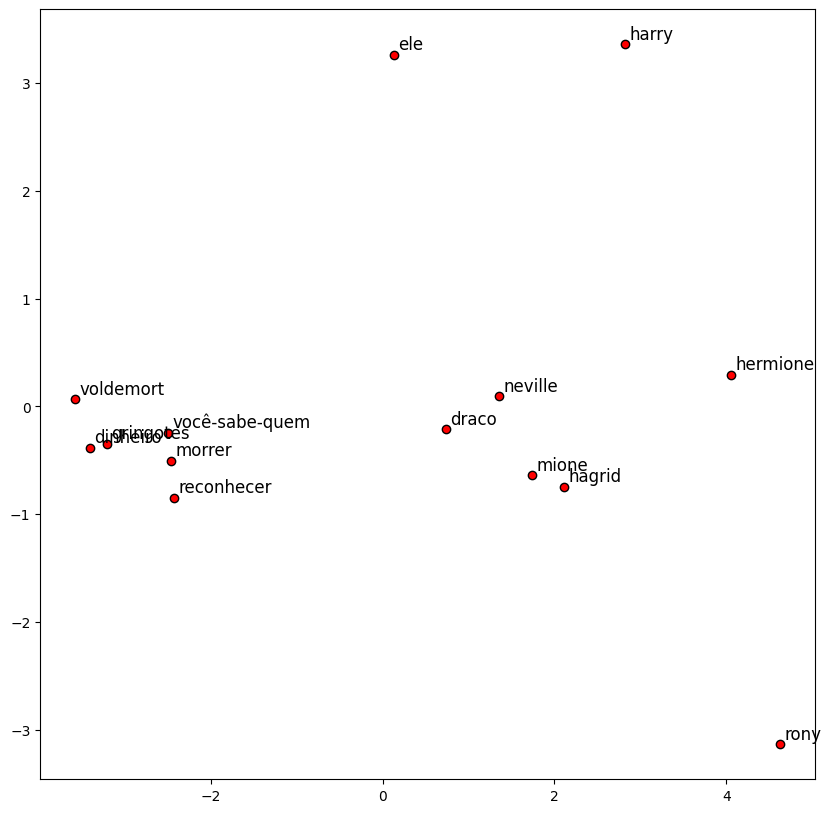

In [26]:

palavras_base = ['harry', 'voldemort', 'hermione']
termos_expandidos = list(palavras_base)  # começa com as bases

for palavra in palavras_base:
    similares = model_hp.wv.most_similar(palavra, topn=5)
    termos_expandidos += [w for w, _ in similares]

termos_expandidos = list(dict.fromkeys(termos_expandidos))

cores_expandido = {}
for w in termos_expandidos:
    if w in ['harry'] + [x for x, _ in model_hp.wv.most_similar('harry', topn=5)]:
        cores_expandido[w] = '#e74c3c'
    elif w in ['voldemort'] + [x for x, _ in model_hp.wv.most_similar('voldemort', topn=5)]:
        cores_expandido[w] = '#2980b9'
    elif w in ['hermione'] + [x for x, _ in model_hp.wv.most_similar('hermione', topn=5)]:
        cores_expandido[w] = '#27ae60'
    else:
        cores_expandido[w] = '#888888'

display_pca_scatterplot(
    model_hp,
    termos_expandidos
)